Loading the best saved Ensemble Model (Epoch 3)...
Evaluating on validation data. This will take a minute...

--- Classification Report ---
              precision    recall  f1-score   support

Lung_Opacity       0.87      0.91      0.89       269
      Normal       0.92      0.86      0.89       317
   Pneumonia       0.99      1.00      1.00       307
          TB       0.96      0.99      0.98       147

    accuracy                           0.93      1040
   macro avg       0.94      0.94      0.94      1040
weighted avg       0.93      0.93      0.93      1040



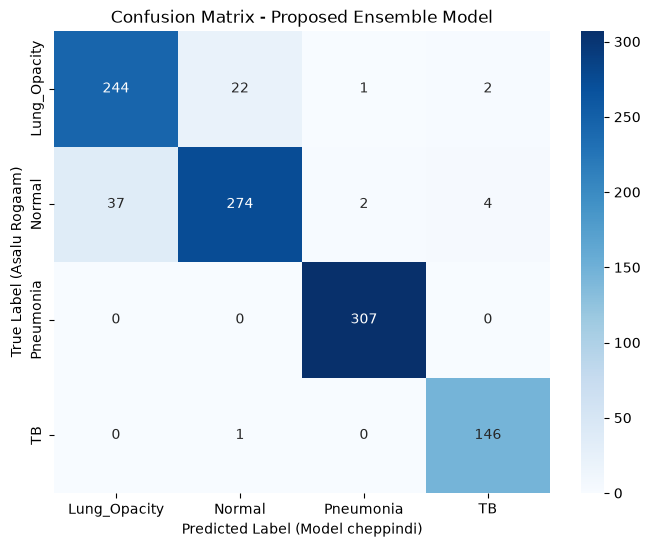

In [13]:
# Cell 12: Confusion Matrix & Classification Report
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("Loading the best saved Ensemble Model (Epoch 3)...")
best_ensemble_model = tf.keras.models.load_model("../models/proposed_ensemble_model.keras")

true_labels = []
predictions = []

print("Evaluating on validation data. This will take a minute...")
# Loop through the validation dataset to get true labels and predict images
for images, labels in val_dataset:
    true_labels.extend(labels.numpy())
    preds = best_ensemble_model.predict(images, verbose=0)
    predicted_classes = np.argmax(preds, axis=1) # Get the index of max probability
    predictions.extend(predicted_classes)

true_labels = np.array(true_labels)
predictions = np.array(predictions)

# 1. Print Classification Report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(true_labels, predictions, target_names=class_names))

# 2. Plot Confusion Matrix
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Proposed Ensemble Model')
plt.xlabel('Predicted Label (Model cheppindi)')
plt.ylabel('True Label (Asalu Rogaam)')
plt.show()

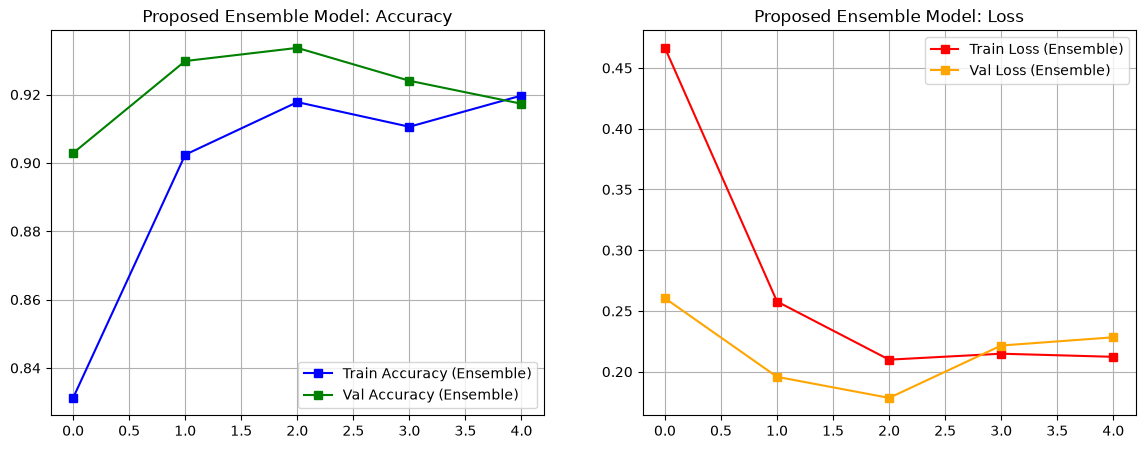

In [12]:
# Cell 11: Plot Ensemble Model Training History
acc_ens = history_ensemble.history['accuracy']
val_acc_ens = history_ensemble.history['val_accuracy']
loss_ens = history_ensemble.history['loss']
val_loss_ens = history_ensemble.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_ens, label='Train Accuracy (Ensemble)', color='blue', marker='s')
plt.plot(epochs_range, val_acc_ens, label='Val Accuracy (Ensemble)', color='green', marker='s')
plt.legend(loc='lower right')
plt.title('Proposed Ensemble Model: Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_ens, label='Train Loss (Ensemble)', color='red', marker='s')
plt.plot(epochs_range, val_loss_ens, label='Val Loss (Ensemble)', color='orange', marker='s')
plt.legend(loc='upper right')
plt.title('Proposed Ensemble Model: Loss')
plt.grid(True)

plt.show()

In [11]:
# Cell 10: Train the Proposed Ensemble Model
import time

# Best accuracy vachinappudu model ni save chese trick
callbacks_ensemble = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/proposed_ensemble_model.keras", 
        save_best_only=True, 
        monitor="val_accuracy"
    )
]

print("Starting Ensemble Model Training... (Combining ResNet50 + EfficientNetB0)")
start_time_ens = time.time()

history_ensemble = ensemble_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS, # Same 5 epochs for fair comparison with baseline
    callbacks=callbacks_ensemble
)

end_time_ens = time.time()
print(f"\nEnsemble Training completed in {(end_time_ens - start_time_ens) / 60:.2f} minutes.")

Starting Ensemble Model Training... (Combining ResNet50 + EfficientNetB0)
Epoch 1/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1516s 12s/step - accuracy: 0.8313 - loss: 0.4665 - val_accuracy: 0.9029 - val_loss: 0.2605
Epoch 2/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 4791s 37s/step - accuracy: 0.9024 - loss: 0.2578 - val_accuracy: 0.9298 - val_loss: 0.1958
Epoch 3/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1056s 8s/step - accuracy: 0.9178 - loss: 0.2099 - val_accuracy: 0.9337 - val_loss: 0.1785
Epoch 4/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1280s 10s/step - accuracy: 0.9106 - loss: 0.2148 - val_accuracy: 0.9240 - val_loss: 0.2216
Epoch 5/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 1233s 9s/step - accuracy: 0.9197 - loss: 0.2123 - val_accuracy: 0.9173 - val_loss: 0.2283

Ensemble Training completed in 164.60 minutes.


In [10]:
# Cell 9: Building the Proposed Ensemble Model
print("Building Ensemble Model (ResNet50 + EfficientNetB0)...")

# 1. Load ResNet50 Branch
resnet_base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
resnet_base.trainable = False # Freeze layers
resnet_preprocess = tf.keras.applications.resnet50.preprocess_input

# 2. Load EfficientNetB0 Branch
efficient_base = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
efficient_base.trainable = False # Freeze layers
efficient_preprocess = tf.keras.applications.efficientnet.preprocess_input

# 3. Create the Combined Architecture
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Apply data augmentation once for both branches
augmented_inputs = data_augmentation(inputs)

# Path 1: ResNet50 Features
x1 = resnet_preprocess(augmented_inputs)
x1 = resnet_base(x1, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)

# Path 2: EfficientNet Features
x2 = efficient_preprocess(augmented_inputs)
x2 = efficient_base(x2, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)

# Combine both feature sets (Concatenation)
combined_features = layers.Concatenate()([x1, x2])

# Add custom classification layers on top of the combined features
x = layers.Dropout(0.3)(combined_features) # 30% dropout to prevent overfitting
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(4, activation='softmax')(x) # 4 classes output

# Final Ensemble Model
ensemble_model = tf.keras.Model(inputs, outputs, name="Proposed_Ensemble_Model")

# Compile the Ensemble Model
ensemble_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

ensemble_model.summary()

Building Ensemble Model (ResNet50 + EfficientNetB0)...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "Proposed_Ensemble_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential[1][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ sequential[1][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 3328)      │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    426,112 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │        516 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,063,911 (107.06 MB)

 Trainable params: 426,628 (1.63 MB)

 Non-trainable params: 27,637,283 (105.43 MB)

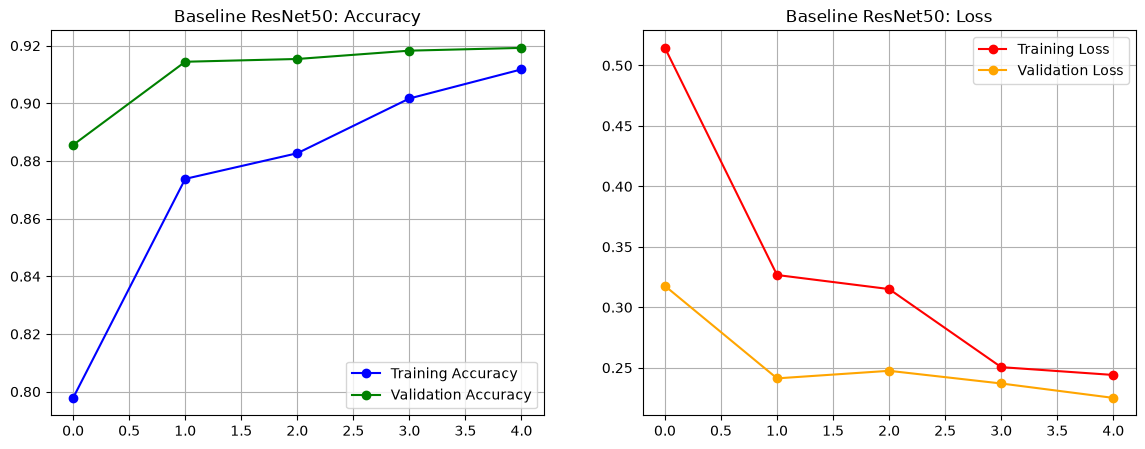

In [9]:
# Cell 8: Plot Training History (Accuracy & Loss Graphs)
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='green', marker='o')
plt.legend(loc='lower right')
plt.title('Baseline ResNet50: Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.legend(loc='upper right')
plt.title('Baseline ResNet50: Loss')
plt.grid(True)

plt.show()

In [8]:
# Cell 7: Train the Baseline ResNet50 Model (Speed Test)
import time
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

EPOCHS = 5  # Speed test kosam first 5 epochs peduthunnam

# Best accuracy vachinappudu model ni save chese automatic trick (Callback)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="../models/baseline_resnet50.keras", 
        save_best_only=True, 
        monitor="val_accuracy"
    )
]

print("Starting Baseline Model Training... Let's check the CPU speed!")
start_time = time.time()

# Ee line daggara training start avuthundi
history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

end_time = time.time()
print(f"\nTraining completed in {(end_time - start_time) / 60:.2f} minutes.")

Starting Baseline Model Training... Let's check the CPU speed!
Epoch 1/5


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


130/130 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.7978 - loss: 0.5145 - val_accuracy: 0.8856 - val_loss: 0.3177
Epoch 2/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 470s 4s/step - accuracy: 0.8738 - loss: 0.3267 - val_accuracy: 0.9144 - val_loss: 0.2412
Epoch 3/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8827 - loss: 0.3151 - val_accuracy: 0.9154 - val_loss: 0.2475
Epoch 4/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 554s 4s/step - accuracy: 0.9017 - loss: 0.2505 - val_accuracy: 0.9183 - val_loss: 0.2370
Epoch 5/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9118 - loss: 0.2441 - val_accuracy: 0.9192 - val_loss: 0.2251

Training completed in 28.49 minutes.


In [7]:
# Cell 6: Build the Baseline Model (ResNet50)
IMG_SHAPE = IMG_SIZE + (3,) # (224, 224, 3) channels

# 1. Load Pre-trained ResNet50 (Without the final layer)
base_model = tf.keras.applications.ResNet50(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze the base model (We only train the top layers for now to save time)
base_model.trainable = False

# 2. Add our custom layers on top
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Prevents overfitting
outputs = layers.Dense(4, activation='softmax')(x) # 4 output classes

baseline_model = tf.keras.Model(inputs, outputs, name="Baseline_ResNet50")

# 3. Compile the model
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Print the model structure
baseline_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "Baseline_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Cell 5: Data Augmentation & Preprocessing
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# Normalize the pixel values for ResNet50
preprocess_input = tf.keras.applications.resnet50.preprocess_input

print("Data Augmentation & Preprocessing layers are ready.")

Data Augmentation & Preprocessing layers are ready.


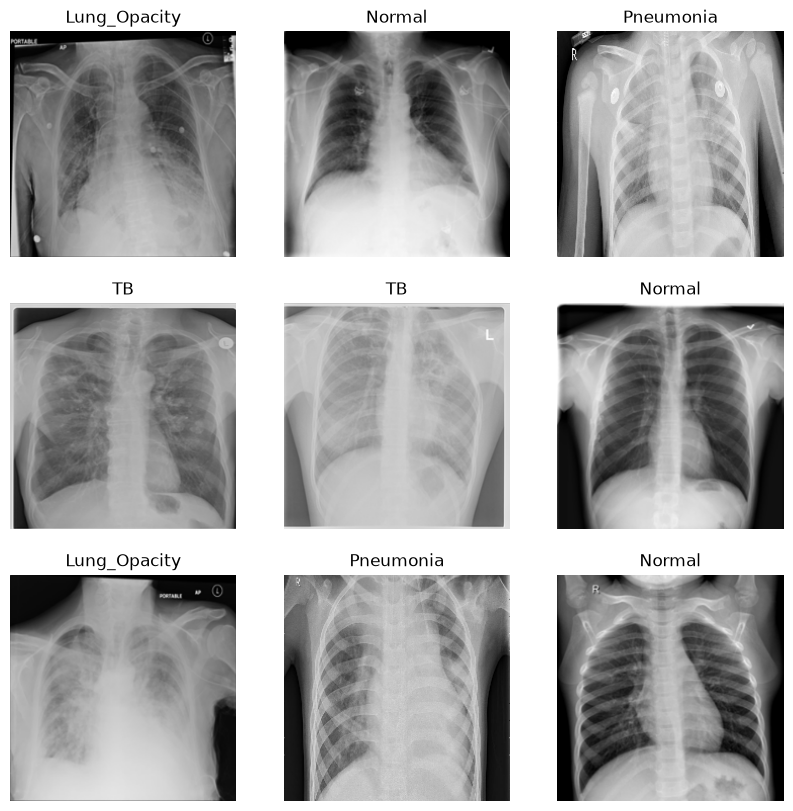

In [5]:
# Cell 4: Visualize sample images
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1): 
    for i in range(9):                       
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [4]:
# Cell 3: Load and Split Dataset
print("Loading Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2, 
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2, 
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("\nOur 4 Classes are:", class_names)

Loading Training Data...
Found 5200 files belonging to 4 classes.
Using 4160 files for training.

Loading Validation Data...
Found 5200 files belonging to 4 classes.
Using 1040 files for validation.

Our 4 Classes are: ['Lung_Opacity', 'Normal', 'Pneumonia', 'TB']


In [3]:
# Cell 2: Configuration & Hyperparameters
DATASET_DIR = "../dataset/Balanced_Dataset" # Notebooks folder nunchi bayatiki vachi dataset loki velthundi
IMG_SIZE = (224, 224)                       # Standard size for our models
BATCH_SIZE = 32                             # Oke sari model ki 32 images istham
SEED = 42                                   # Randomness ni fix cheyadaniki

In [2]:
# Cell 1: Import necessary libraries
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available:  []
